# Sistema Multiagente de Accesibilidad para Adultos Mayores
## Clasificacion de intencion en español ecuatoriano coloquial

### Problema

Los adultos mayores tienen dificultad para usar asistentes digitales. Hablan de forma coloquial, con modismos ecuatorianos, y no usan las palabras clave que esperan los sistemas tradicionales. El reto es entender la intencion detras de la frase, no las palabras exactas. Si el sistema confunde una emergencia con una consulta trivial, las consecuencias para el usuario pueden ser graves.

El objetivo de este trabajo es clasificar de forma automatica la intencion de una frase para enrutarla al agente especialista correcto.

### Intenciones

El sistema distingue cinco intenciones:

- `MEDICATION_HEALTH`: medicacion, dosis, horarios, sintomas.
- `RECIPE_MULTIMEDIA`: recetas y guias de cocina paso a paso.
- `FAMILY_COMMUNICATION`: enviar avisos o mensajes a familiares.
- `EMERGENCY`: caidas, dolor intenso, peligro en el entorno.
- `SMALL_TALK`: saludos y conversacion trivial.


## Metodologia

El proyecto sigue el flujo estandar de un problema de machine learning supervisado de clasificacion de texto:

1. Definicion del problema y de las clases objetivo.
2. Carga y exploracion de los datos, con nube de palabras y frecuencias.
3. Division estratificada en entrenamiento y prueba.
4. Extraccion de caracteristicas con dos representaciones, TF-IDF y embeddings.
5. Entrenamiento de un modelo base y un modelo mejorado con la misma cabeza.
6. Optimizacion de hiperparametros con validacion cruzada y curva de aprendizaje.
7. Evaluacion estadistica con accuracy, F1 macro, curva ROC y AUC.
8. Analisis de errores del mejor modelo.
9. Persistencia del modelo entrenado.
10. Aplicacion en un sistema multiagente y comparacion de estrategias de ruteo.

## 1. Preparacion del entorno

In [54]:
# Para correr en google colab
!pip install sentence-transformers wordcloud -q

In [55]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import joblib

# Rutas. Funciona en local y en Google Colab.
# Para Colab, reemplaza USUARIO_GITHUB por tu usuario una vez publicado el repositorio.
USUARIO_GITHUB = 'mpillapa'
REPO_GITHUB    = 'accessibility-agents'
URL_BASE = f'https://raw.githubusercontent.com/{USUARIO_GITHUB}/{REPO_GITHUB}/main'

def ruta_dato(relativa):
    # Devuelve la ruta local si el archivo existe, o la URL del repositorio si no.
    for candidata in [os.path.join('..', relativa), relativa]:
        if os.path.exists(candidata):
            return candidata
    return f'{URL_BASE}/{relativa}'

## 2. Carga y exploracion del dataset

El dataset propio tiene 415 frases en espanol ecuatoriano coloquial, balanceado con 83 frases por intencion. La definicion completa de cada clase con ejemplos esta en data/intents/intents_schema.md del repositorio.

In [56]:
# Carga el dataset desde local o desde GitHub segun el entorno
df = pd.read_csv(ruta_dato('data/intents/dataset.csv'))
print(f'Total de frases: {len(df)}')

# Lista ordenada de las 5 clases; se reutiliza en graficos y matrices
INTENCIONES = sorted(df['intent'].unique())
# Nombres cortos para que no se encimen en los ejes
ETIQUETAS_CORTAS = [e.split('_')[0] for e in INTENCIONES]

df.head()

Total de frases: 415


,intent,text
0,MEDICATION_HEALTH,Oye mijito ¿ya me toca tomar la pastillita del...
1,MEDICATION_HEALTH,¿A qué hora me corresponde el jarabe que me re...
2,MEDICATION_HEALTH,Tengo un dolorcito en la rodilla desde ayer ¿s...
3,FAMILY_COMMUNICATION,Quiero mandarle un mensajito a mi hijo Carlos ...
4,FAMILY_COMMUNICATION,¿Puedes avisarle a mi hija María que ya tomé l...


intent
EMERGENCY               83
FAMILY_COMMUNICATION    83
MEDICATION_HEALTH       83
RECIPE_MULTIMEDIA       83
SMALL_TALK              83


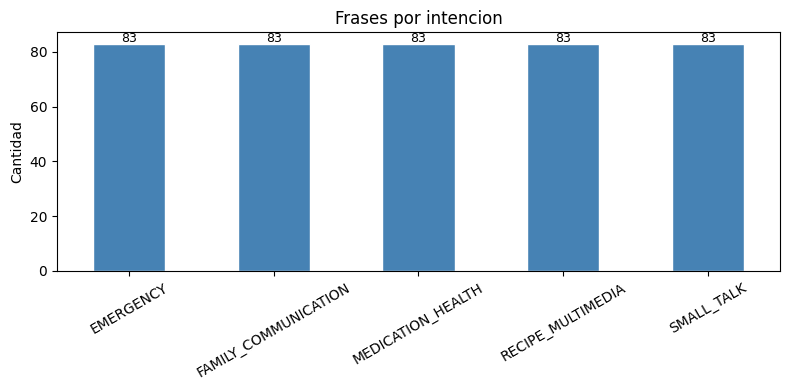

In [57]:
# Cuenta cuantas frases hay por intencion, en orden alfabetico
conteo = df['intent'].value_counts().sort_index()
print(conteo.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
conteo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Frases por intencion')
ax.set_ylabel('Cantidad')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
# Escribe el numero exacto encima de cada barra
for barra in ax.patches:
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
            str(int(barra.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\Manuel Pillapa\AppData\Local\Temp\ipykernel_27624\2621007068.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_longitud, labels=ETIQUETAS_CORTAS)


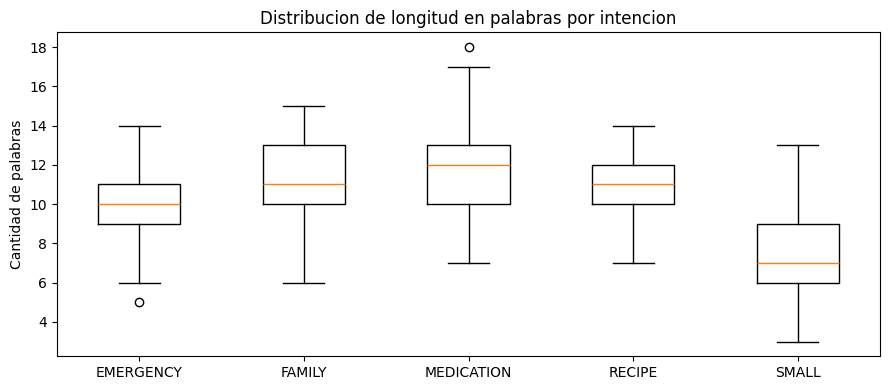

In [58]:
# Longitud de cada frase en numero de palabras
df['longitud'] = df['text'].str.split().str.len()
# Una lista de longitudes por cada intencion, para el boxplot
datos_longitud = [df[df['intent'] == i]['longitud'].values for i in INTENCIONES]

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(datos_longitud, labels=ETIQUETAS_CORTAS)
ax.set_title('Distribucion de longitud en palabras por intencion')
ax.set_ylabel('Cantidad de palabras')
plt.tight_layout()
plt.show()

In [59]:
for intencion in INTENCIONES:
    print()
    print(intencion)
    muestra = df[df['intent'] == intencion]['text'].sample(3, random_state=42)
    for texto in muestra:
        print(f'  - {texto}')


EMERGENCY
  - Necesito que vengan ya me está pasando algo
  - Me caí en el baño y no me puedo levantar ayúdame por favor
  - Me siento muy mal el corazón late rápido y me falta el aire

FAMILY_COMMUNICATION
  - Marca a mi sobrina que hace meses no hablo con ella
  - Quiero mandarle un mensajito a mi hijo Carlos que está en Quito
  - ¿Hay algún aviso de la familia que deba saber?

MEDICATION_HEALTH
  - Siempre me confundo ¿son dos comprimidos blancos o uno blanco y uno amarillo?
  - Oye mijito ¿ya me toca tomar la pastillita del corazón?
  - Listo ya me tomé el calmante ¿lo registras?

RECIPE_MULTIMEDIA
  - Espera espera ¿me repites lo del refrito que no entendí?
  - ¿Me lees la receta del locro de papas pasito a pasito?
  - Dice una libra de carne ¿eso cuánto es en gramos más o menos?

SMALL_TALK
  - ¿Puedes hacer cualquier cosa o tienes límites?
  - Buenos días mijito ¿cómo amaneciste hoy?
  - Oye hace tanto viento que la ventana no para de sonar


## 3. Analisis exploratorio: nube de palabras y frecuencias

El dominio es texto coloquial. Se visualizan las palabras que dominan el corpus y si hay solapamiento de vocabulario entre intenciones. Mucho solapamiento anticipa dificultades para un clasificador basado en conteo de palabras como TF-IDF.

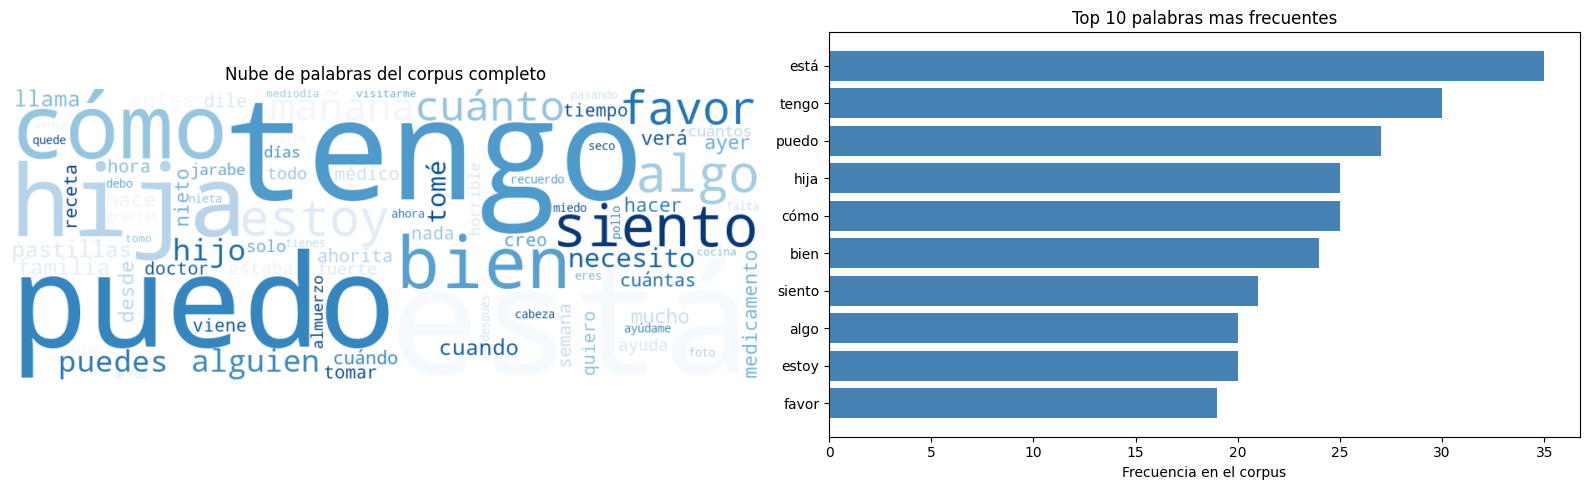

Palabras mas frecuentes por intencion:
EMERGENCY             : puedo, siento, estoy, está, alguien
FAMILY_COMMUNICATION  : hija, hijo, familia, dile, puedes
MEDICATION_HEALTH     : tomé, pastillas, tengo, medicamento, mañana
RECIPE_MULTIMEDIA     : cómo, cuánto, receta, bien, tiempo
SMALL_TALK            : está, gracias, todo, eres, nada


In [60]:
from wordcloud import WordCloud

# Palabras vacias que no aportan significado y se descartan del analisis
STOPWORDS_ES = {
    'de', 'que', 'el', 'la', 'en', 'es', 'me', 'mi', 'te', 'le', 'se',
    'un', 'una', 'los', 'las', 'al', 'del', 'ya', 'no', 'si', 'por',
    'con', 'para', 'como', 'hay', 'lo', 'su', 'tu', 'yo', 'pero', 'mas',
    'muy', 'he', 'ha', 'son', 'tan', 'fue', 'ser', 'han', 'esta', 'este'
}

def tokenizar(texto):
    # Quita puntuacion, pasa a minusculas y deja solo palabras de 4 letras o mas
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    return [p for p in texto.split() if p not in STOPWORDS_ES and len(p) >= 4]

# Frecuencia de palabras en todo el corpus
todo_tokens = tokenizar(' '.join(df['text'].tolist()))
frecuencias_global = Counter(todo_tokens)

# Nube de palabras: el tamano de cada palabra es proporcional a su frecuencia
wc = WordCloud(width=900, height=350, background_color='white', colormap='Blues', max_words=80)
wc.generate_from_frequencies(frecuencias_global)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Nube de palabras del corpus completo')

# Las 10 palabras mas frecuentes, en barras horizontales
top10 = frecuencias_global.most_common(10)
palabras_top, freqs_top = zip(*top10)
axes[1].barh(range(len(palabras_top)), list(reversed(freqs_top)), color='steelblue')
axes[1].set_yticks(range(len(palabras_top)))
axes[1].set_yticklabels(list(reversed(palabras_top)), fontsize=10)
axes[1].set_xlabel('Frecuencia en el corpus')
axes[1].set_title('Top 10 palabras mas frecuentes')
plt.tight_layout()
plt.show()

# Las 5 palabras mas frecuentes de cada intencion por separado
print('Palabras mas frecuentes por intencion:')
for intencion in INTENCIONES:
    tokens = tokenizar(' '.join(df[df['intent'] == intencion]['text'].tolist()))
    top5 = [p for p, _ in Counter(tokens).most_common(5)]
    print(f'{intencion:<22}: {", ".join(top5)}')

## 4. Division en entrenamiento y prueba

Se divide 80 por ciento para entrenamiento y 20 por ciento para prueba, de forma estratificada para que cada intencion conserve su proporcion en ambos conjuntos. La semilla fija en 42 hace el resultado reproducible.

In [61]:
# 80% entrenamiento, 20% prueba. stratify mantiene la proporcion de cada
# intencion en ambos grupos; random_state fija la division para reproducirla
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    df['text'].tolist(),
    df['intent'].tolist(),
    test_size=0.2,
    stratify=df['intent'],
    random_state=42
)

print(f'Frases de entrenamiento: {len(X_entrenamiento)}')
print(f'Frases de prueba: {len(X_prueba)}')

# Verifica que el balance entre clases se mantuvo en ambos grupos
resumen_split = pd.DataFrame({
    'Train': pd.Series(y_entrenamiento).value_counts().sort_index(),
    'Test':  pd.Series(y_prueba).value_counts().sort_index()
})
resumen_split

Frases de entrenamiento: 332
Frases de prueba: 83


,Train,Test
EMERGENCY,66,17
FAMILY_COMMUNICATION,67,16
MEDICATION_HEALTH,66,17
RECIPE_MULTIMEDIA,66,17
SMALL_TALK,67,16


## 5. Extraccion de caracteristicas y modelo base: TF-IDF + Logistic Regression

Primera representacion: TF-IDF con unigramas y bigramas. Convierte cada frase en un vector de frecuencias de palabras y pares de palabras, ponderado por que tan informativa es cada termino en el corpus.

No se eliminan stopwords. En frases cortas y coloquiales, palabras como me, ya u oye ayudan a distinguir intenciones, asi que quitarlas perderia senal.

La cabeza del clasificador es Logistic Regression con class_weight balanceado, para que ninguna intencion domine por cantidad.

In [62]:
# ngram_range (1,2): palabras sueltas y pares. min_df=2: ignora terminos raros.
# No se quitan stopwords: en frases cortas palabras como "ya" u "oye" dan señal.
vectorizador_tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, lowercase=True, strip_accents='unicode')

# fit_transform aprende el vocabulario solo del entrenamiento;
# en el test solo se transforma, para no filtrarle informacion 
X_tfidf_train = vectorizador_tfidf.fit_transform(X_entrenamiento)
X_tfidf_test  = vectorizador_tfidf.transform(X_prueba)

# class_weight balanced evita que una clase pese mas que otra al entrenar
logreg_tfidf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_tfidf.fit(X_tfidf_train, y_entrenamiento)

predicciones_tfidf = logreg_tfidf.predict(X_tfidf_test)
print(classification_report(y_prueba, predicciones_tfidf, target_names=INTENCIONES))

                      precision    recall  f1-score   support

           EMERGENCY       0.83      0.88      0.86        17
FAMILY_COMMUNICATION       0.94      1.00      0.97        16
   MEDICATION_HEALTH       0.88      0.82      0.85        17
   RECIPE_MULTIMEDIA       0.74      0.82      0.78        17
          SMALL_TALK       0.92      0.75      0.83        16

            accuracy                           0.86        83
           macro avg       0.86      0.86      0.86        83
        weighted avg       0.86      0.86      0.86        83



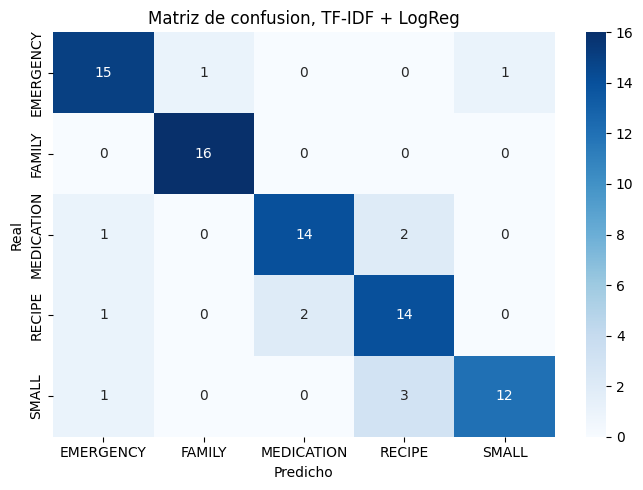

In [63]:
# Filas: intencion real. Columnas: predicha. La diagonal son los aciertos
cm_tfidf = confusion_matrix(y_prueba, predicciones_tfidf, labels=INTENCIONES)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues', xticklabels=ETIQUETAS_CORTAS, yticklabels=ETIQUETAS_CORTAS)
plt.title('Matriz de confusion, TF-IDF + LogReg')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [64]:
# make_pipeline reajusta el TF-IDF en cada particion
# Sin pipeline el vocabulario se aprenderia del dataset completo y habria fuga de datos
puntajes_cv_tfidf = cross_val_score(
    make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, lowercase=True, strip_accents='unicode'),
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    ),
    X_entrenamiento, y_entrenamiento, cv=5, scoring='accuracy'
)
print(f'CV 5-fold TF-IDF, accuracy: {puntajes_cv_tfidf.mean():.4f} mas menos {puntajes_cv_tfidf.std():.4f}')

CV 5-fold TF-IDF, accuracy: 0.7440 mas menos 0.0192


### Analisis del modelo base

El modelo TF-IDF con Logistic Regression alcanza un accuracy cercano al 85 por ciento. Es un punto de partida razonable, pero falla en tres patrones:

- Small talk contra recetas. Preguntas como cuanto falta para navidad no tienen vocabulario de cocina, pero al no tener vocabulario propio el modelo las asigna a la clase con mayor solapamiento superficial.
- Medicacion contra comunicacion familiar. Frases sin nombres de medicamentos ni sintomas explicitos se apoyan en co ocurrencias de palabras poco discriminativas.
- Emergencia con urgencia implicita. Frases como que alguien venga ahorita no tienen terminos de emergencia explicitos, asi que TF-IDF no capta la urgencia.

La causa de fondo es que TF-IDF mide presencia y frecuencia de palabras, no significado. Dos frases opuestas pueden parecer similares si comparten preposiciones, y dos frases equivalentes pueden parecer distintas si usan sinonimos coloquiales.

## 6. Modelo mejorado: embeddings MiniLM + Logistic Regression

Segunda representacion: embeddings del modelo paraphrase-multilingual-MiniLM-L12-v2. En lugar de contar palabras, codifica cada frase en un vector de 384 dimensiones que captura su significado. Frases parecidas en sentido quedan cerca en el espacio vectorial aunque usen palabras distintas.

La cabeza es la misma Logistic Regression. Al cambiar solo el representador, la diferencia de resultados mide el aporte de la representacion.

In [65]:
from sentence_transformers import SentenceTransformer

# Se carga el modelo multilingue MiniLM para generar embeddings de las frases en español
modelo_minilm = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [66]:
# El encoder es preentrenado y fijo, no se entrena en este notebook
# Solo se usa para generar embeddings de las frases
X_emb_train = modelo_minilm.encode(X_entrenamiento, show_progress_bar=True)
X_emb_test  = modelo_minilm.encode(X_prueba, show_progress_bar=True)

print(f'Dimension de cada embedding: {X_emb_train.shape[1]}')

logreg_emb = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_emb.fit(X_emb_train, y_entrenamiento)

predicciones_emb = logreg_emb.predict(X_emb_test)
print(classification_report(y_prueba, predicciones_emb, target_names=INTENCIONES))

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Dimension de cada embedding: 384
                      precision    recall  f1-score   support

           EMERGENCY       1.00      0.88      0.94        17
FAMILY_COMMUNICATION       0.88      0.94      0.91        16
   MEDICATION_HEALTH       1.00      0.88      0.94        17
   RECIPE_MULTIMEDIA       0.85      1.00      0.92        17
          SMALL_TALK       0.88      0.88      0.88        16

            accuracy                           0.92        83
           macro avg       0.92      0.92      0.92        83
        weighted avg       0.92      0.92      0.92        83



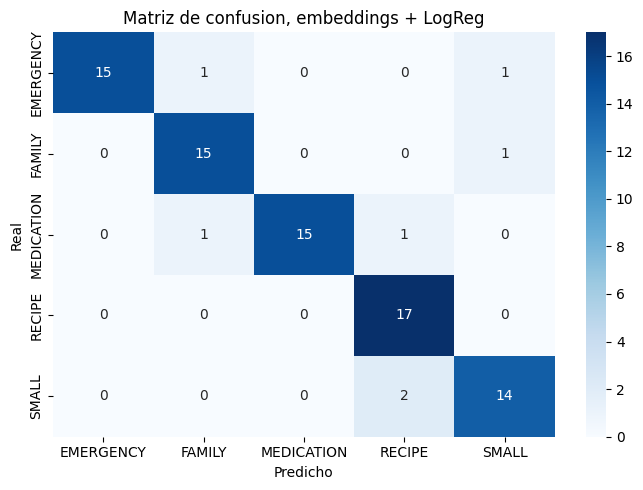

In [67]:
# Crea la matriz de confusion para embeddings + Logistic Regression
cm_emb = confusion_matrix(y_prueba, predicciones_emb, labels=INTENCIONES)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_emb, annot=True, fmt='d', cmap='Blues', xticklabels=ETIQUETAS_CORTAS, yticklabels=ETIQUETAS_CORTAS)
plt.title('Matriz de confusion, embeddings + LogReg')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [68]:
# cross_val_score con embeddings no necesita pipeline porque el encoder es fijo y no se entrena
puntajes_cv_emb = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_emb_train, y_entrenamiento, cv=5, scoring='accuracy'
)
print(f'CV 5-fold embeddings, accuracy: {puntajes_cv_emb.mean():.4f} mas menos {puntajes_cv_emb.std():.4f}')

CV 5-fold embeddings, accuracy: 0.8735 mas menos 0.0399


### Analisis del modelo con embeddings

El modelo con embeddings MiniLM mejora en todas las intenciones. El accuracy sube a cerca del 92 por ciento y el F1 macro tambien. La mayor ganancia esta en emergencia y medicacion.

Mejora porque MiniLM fue preentrenado con pares de frases semanticamente relacionadas en varios idiomas. Entiende que necesito ayuda ya y marca el 911 significan lo mismo aunque no compartan palabras. TF-IDF las ve como vectores sin relacion.

Donde persisten errores es en small talk. Preguntas meta como que tanto sabes activan representaciones de otros dominios. Y una taquicardia enviada a comunicacion familiar sugiere que el modelo prioriza la intencion de llamar a alguien sobre la urgencia clinica.

## 7. Optimizacion de hiperparametros y curva de aprendizaje

El hiperparametro a optimizar es C de Logistic Regression, el inverso de la fuerza de regularizacion. Un C pequeño regulariza mas, sube el sesgo y baja la varianza. Un C grande hace lo contrario.

Se barre C en escala logaritmica de 0.001 a 1000 y se mide el error por validacion cruzada de 5 particiones. La curva de aprendizaje muestra como cambia el error de entrenamiento y de validacion al aumentar el tamano del dataset. Se usa log loss porque con embeddings el modelo clasifica su propio set de forma perfecta, asi que el log loss revela la confianza de la prediccion donde el F1 ya no informa.

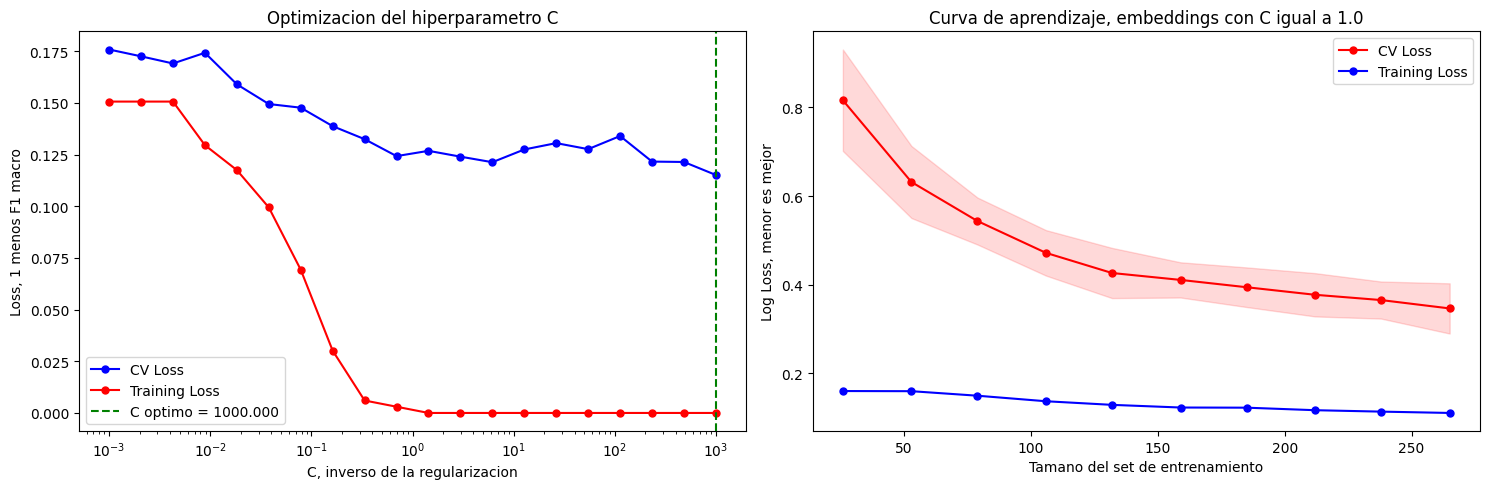

C optimo: 1000.0000
F1 macro CV en C optimo: 0.8849


In [69]:
# Optimizacion del hiperparametro C
C_values = np.logspace(-3, 3, 20)
train_scores_C, cv_scores_C = [], []

# Entrenamos un modelo para cada valor de C y guarda el F1 macro de entrenamiento y CV
for C in C_values:
    modelo_C = LogisticRegression(C=C, max_iter=1000, class_weight='balanced', random_state=42)
    modelo_C.fit(X_emb_train, y_entrenamiento)
    train_scores_C.append(modelo_C.score(X_emb_train, y_entrenamiento))
    cv = cross_val_score(modelo_C, X_emb_train, y_entrenamiento, cv=5, scoring='f1_macro')
    cv_scores_C.append(cv.mean())

# Convertimos F1 macro a loss (1 - F1) para graficar
train_loss_C = [1 - s for s in train_scores_C]
cv_loss_C    = [1 - s for s in cv_scores_C]
idx_optimo   = int(np.argmin(cv_loss_C))
C_optimo     = C_values[idx_optimo]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].semilogx(C_values, cv_loss_C,    'b-o', markersize=5, label='CV Loss')
axes[0].semilogx(C_values, train_loss_C, 'r-o', markersize=5, label='Training Loss')
axes[0].axvline(C_optimo, color='green', linestyle='--', label=f'C optimo = {C_optimo:.3f}')
axes[0].set_xlabel('C, inverso de la regularizacion')
axes[0].set_ylabel('Loss, 1 menos F1 macro')
axes[0].set_title('Optimizacion del hiperparametro C')
axes[0].legend()

# Curva de aprendizaje con log loss.
# Con embeddings de 384 dimensiones y pocas muestras el modelo clasifica su
# propio set de forma perfecta, asi que el F1 de entrenamiento es 1.0 siempre.
# El log loss mide la confianza de la prediccion, no solo si acierta, por lo
# que da una curva informativa aunque el accuracy sea 100 por ciento.
train_sizes, tr_sc, cv_sc = learning_curve(
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42),
    X_emb_train, y_entrenamiento,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_log_loss'
)

tr_loss    = -tr_sc.mean(axis=1)
cv_loss_lc = -cv_sc.mean(axis=1)
cv_std_lc  =  cv_sc.std(axis=1)

axes[1].plot(train_sizes, cv_loss_lc, 'r-o', markersize=5, label='CV Loss')
axes[1].fill_between(train_sizes, cv_loss_lc - cv_std_lc, cv_loss_lc + cv_std_lc, alpha=0.15, color='red')
axes[1].plot(train_sizes, tr_loss, 'b-o', markersize=5, label='Training Loss')
axes[1].set_xlabel('Tamano del set de entrenamiento')
axes[1].set_ylabel('Log Loss, menor es mejor')
axes[1].set_title('Curva de aprendizaje, embeddings con C igual a 1.0')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'C optimo: {C_optimo:.4f}')
print(f'F1 macro CV en C optimo: {max(cv_scores_C):.4f}')

## 8. Comparacion estadistica: curva ROC y AUC

Ademas de accuracy y F1, se evalua con curva ROC y AUC. Como hay cinco clases, se usa la estrategia One vs Rest: para cada intencion se traza una curva ROC tratando esa clase como positiva y el resto como negativa. El AUC macro es el promedio de los cinco valores. El AUC resume la capacidad de separar clases en todos los umbrales de decision, no solo en el de por defecto.

In [80]:
# Comparacion de resultados entre TF-IDF y embeddings
acc_tfidf = accuracy_score(y_prueba, predicciones_tfidf)
acc_emb   = accuracy_score(y_prueba, predicciones_emb)
f1_tfidf  = f1_score(y_prueba, predicciones_tfidf, average='macro')
f1_emb    = f1_score(y_prueba, predicciones_emb,   average='macro')

tabla_comparacion = pd.DataFrame({
    'Modelo':   ['TF-IDF + LogReg', 'Embeddings + LogReg'],
    'Accuracy': [round(acc_tfidf, 4), round(acc_emb, 4)],
    'F1 macro': [round(f1_tfidf, 4),  round(f1_emb, 4)],
    'CV media': [round(puntajes_cv_tfidf.mean(), 4), round(puntajes_cv_emb.mean(), 4)],
    'CV std':   [round(puntajes_cv_tfidf.std(), 4),  round(puntajes_cv_emb.std(), 4)],
})
tabla_comparacion

,Modelo,Accuracy,F1 macro,CV media,CV std
0,TF-IDF + LogReg,0.8554,0.8561,0.7440,0.0192
1,Embeddings + LogReg,0.9157,0.9156,0.8735,0.0399


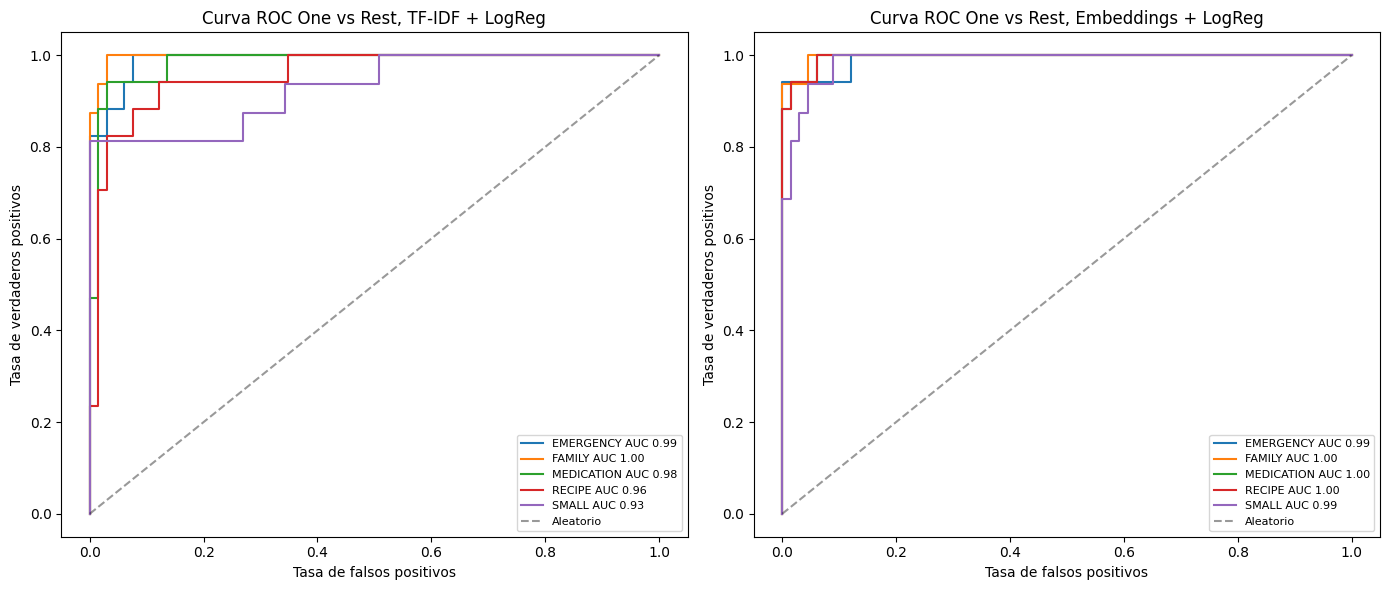

,Modelo,Accuracy,F1 macro,AUC macro
0,TF-IDF + LogReg,0.8554,0.8561,0.9717
1,Embeddings + LogReg,0.9157,0.9156,0.9938


In [71]:
# One vs Rest: binariza las etiquetas, una columna de 0 y 1 por clase
y_bin = label_binarize(y_prueba, classes=INTENCIONES)
# Probabilidad que cada modelo asigna a cada clase
y_prob_tfidf = logreg_tfidf.predict_proba(X_tfidf_test)
y_prob_emb   = logreg_emb.predict_proba(X_emb_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores_roc = plt.cm.tab10.colors

# Una curva ROC por intencion, en cada uno de los dos modelos
for ax, y_prob, titulo in [(axes[0], y_prob_tfidf, 'TF-IDF + LogReg'), (axes[1], y_prob_emb, 'Embeddings + LogReg')]:
    for i, intencion in enumerate(INTENCIONES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colores_roc[i], label=f'{intencion.split("_")[0]} AUC {auc_score:.2f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio')
    ax.set_xlabel('Tasa de falsos positivos')
    ax.set_ylabel('Tasa de verdaderos positivos')
    ax.set_title(f'Curva ROC One vs Rest, {titulo}')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

# AUC macro: promedio del area bajo la curva de las 5 clases
auc_macro_tfidf = roc_auc_score(y_bin, y_prob_tfidf, average='macro', multi_class='ovr')
auc_macro_emb   = roc_auc_score(y_bin, y_prob_emb,   average='macro', multi_class='ovr')

tabla_auc = pd.DataFrame({
    'Modelo':    ['TF-IDF + LogReg', 'Embeddings + LogReg'],
    'Accuracy':  [round(acc_tfidf, 4), round(acc_emb, 4)],
    'F1 macro':  [round(f1_tfidf, 4),  round(f1_emb, 4)],
    'AUC macro': [round(auc_macro_tfidf, 4), round(auc_macro_emb, 4)],
})
tabla_auc

### Interpretacion de la comparacion estadistica

El modelo con embeddings gana en accuracy, F1 macro y AUC macro. El AUC confirma que separa mejor las clases en todos los umbrales de decision, no solo en el punto por defecto.

El costo extra de los embeddings vale la pena. En un sistema de accesibilidad una confusion entre emergencia y small talk puede tener consecuencias graves para el adulto mayor, y la ganancia reduce justo esos errores de alta consecuencia. Ademas, calcular el embedding tarda menos de medio segundo en CPU, un tiempo despreciable frente a los segundos que tarda el agente en responder.

## 9. Analisis de errores del mejor modelo

Se listan todas las frases mal clasificadas por el mejor modelo, junto con la confianza con que se equivoco. Sirve para distinguir errores claros de ambiguedades reales del lenguaje.

In [72]:
# Elige el mejor modelo por F1 macro y se queda con sus predicciones
if f1_emb >= f1_tfidf:
    predicciones_mejor = predicciones_emb
    probas_mejor       = logreg_emb.predict_proba(X_emb_test)
    nombre_mejor       = 'Embeddings + LogReg'
else:
    predicciones_mejor = predicciones_tfidf
    probas_mejor       = logreg_tfidf.predict_proba(X_tfidf_test)
    nombre_mejor       = 'TF-IDF + LogReg'

print(f'Mejor modelo: {nombre_mejor}')

# Recorre el test y guarda solo las frases mal clasificadas
errores = []
for frase, real, pred, probas in zip(X_prueba, y_prueba, predicciones_mejor, probas_mejor):
    if real != pred:
        # confianza = probabilidad maxima, que tan seguro estaba el modelo al fallar
        errores.append({'frase': frase, 'real': real, 'predicha': pred, 'confianza': round(float(probas.max()), 3)})

df_errores = pd.DataFrame(errores)
print(f'Errores: {len(df_errores)} de {len(X_prueba)}')
df_errores

Mejor modelo: Embeddings + LogReg
Errores: 7 de 83


,frase,real,predicha,confianza
0,Por favor que alguien venga ahorita mismo,EMERGENCY,SMALL_TALK,0.713
1,¿Cuánto falta para navidad?,SMALL_TALK,RECIPE_MULTIMEDIA,0.536
2,Anota que el frasco del diurético está casi va...,MEDICATION_HEALTH,RECIPE_MULTIMEDIA,0.684
3,El prospecto dice una cosa y el doctor dijo ot...,MEDICATION_HEALTH,FAMILY_COMMUNICATION,0.455
4,¿Hay algo especial en la familia para las fies...,FAMILY_COMMUNICATION,SMALL_TALK,0.801
5,Me está dando taquicardia y no puedo controlarla,EMERGENCY,FAMILY_COMMUNICATION,0.497
6,¿Cómo sabes tanto si eres una máquina?,SMALL_TALK,RECIPE_MULTIMEDIA,0.517


In [73]:
if len(df_errores) > 0:
    pares = df_errores.groupby(['real', 'predicha']).size().reset_index(name='cantidad').sort_values('cantidad', ascending=False)
    print('Pares de confusion, real hacia predicha:')
    print(pares.to_string(index=False))

Pares de confusion, real hacia predicha:
                real             predicha  cantidad
          SMALL_TALK    RECIPE_MULTIMEDIA         2
           EMERGENCY FAMILY_COMMUNICATION         1
           EMERGENCY           SMALL_TALK         1
FAMILY_COMMUNICATION           SMALL_TALK         1
   MEDICATION_HEALTH FAMILY_COMMUNICATION         1
   MEDICATION_HEALTH    RECIPE_MULTIMEDIA         1


### Lectura de los errores

El mejor modelo comete alrededor de 7 errores en 83 frases, cerca del 8 por ciento. La mayoria son ambiguedades legitimas:

- Que alguien venga ahorita mismo, sin contexto, podria ser cualquier intencion.
- Una taquicardia suena a llamar a alguien antes que a emergencia inmediata.
- Un frasco casi vacio usa la palabra frasco, que el modelo asocia a recetas.

El unico fallo con consecuencia de seguridad es la taquicardia clasificada como comunicacion familiar. Ese caso senala la proxima mejora del dataset: agregar mas frases de sintomas cardiacos.

## 10. Guardado del modelo

Se guarda el mejor modelo en disco para que el sistema de agentes lo cargue sin reentrenar. No se guarda el encoder de embeddings porque pesa mucho y se recarga aparte desde el codigo del clasificador.

In [74]:
if nombre_mejor == 'Embeddings + LogReg':
    paquete = {'tipo': 'embeddings', 'clasificador': logreg_emb, 'etiquetas': list(logreg_emb.classes_)}
else:
    paquete = {'tipo': 'tfidf', 'vectorizador': vectorizador_tfidf, 'clasificador': logreg_tfidf, 'etiquetas': list(logreg_tfidf.classes_)}

joblib.dump(paquete, 'modelo.joblib')
print(f'Modelo guardado. Tipo: {paquete["tipo"]}')
print(f'Etiquetas: {paquete["etiquetas"]}')

Modelo guardado. Tipo: embeddings
Etiquetas: [np.str_('EMERGENCY'), np.str_('FAMILY_COMMUNICATION'), np.str_('MEDICATION_HEALTH'), np.str_('RECIPE_MULTIMEDIA'), np.str_('SMALL_TALK')]


## 11. Aplicacion: sistema multiagente

El clasificador no es el fin en si mismo. Es el router de un sistema multiagente construido con CrewAI y un modelo de lenguaje local, qwen2.5:7b servido por Ollama. Cada intencion tiene su propio agente especialista.

El sistema corre en local porque necesita Ollama instalado en la maquina. El codigo completo esta en src/agentes.py del repositorio. A continuacion se resume la arquitectura y las tres estrategias de ruteo que probe.

### Arquitectura

```
Usuario -> Orchestrator -> [ Medicacion | Recetas | Familia | Emergencia | Small talk ]
```

### Tres estrategias de ruteo

La pregunta de fondo es quien decide a que especialista enviar cada consulta. Probe tres respuestas distintas.

Estrategia B. El modelo de lenguaje del Orchestrator lee la consulta y decide por su cuenta a quien delegar. No usa el clasificador.

```python
# Nota de autoria: la estructura base de los agentes con CrewAI se desarrollo
# con ayuda de Claude. Prompt de referencia que se le dio:
#   "Como armo en CrewAI un Orchestrator que delegue la consulta a agentes
#    especialistas segun la intencion, y como expongo mi clasificador de
#    scikit-learn como una herramienta del agente?"
def procesar_consulta_v_b(consulta):
    # B: el modelo de lenguaje del Orchestrator razona y delega solo
    crew = crear_crew()  # Orchestrator mas 4 especialistas
    return crew.kickoff(inputs={'consulta': consulta})
```

Estrategia A1. El clasificador entrenado decide la intencion y un despachador de Python llama directo al especialista. El modelo de lenguaje no interviene en la decision de ruteo.

```python
def procesar_consulta_v_a1(consulta):
    # A1: el clasificador decide y Python despacha directo al especialista
    intencion = predecir(consulta)['intencion']
    if intencion == 'MEDICATION_HEALTH':
        return ejecutar(crear_agente_medicacion(), consulta)
    elif intencion == 'RECIPE_MULTIMEDIA':
        return ejecutar(crear_agente_recetas(), consulta)
    elif intencion == 'FAMILY_COMMUNICATION':
        return ejecutar(crear_agente_familia(), consulta)
    elif intencion == 'EMERGENCY':
        return ejecutar(crear_agente_emergencia(), consulta)
    else:
        return 'Hola, en que puedo ayudarte hoy'
```

Estrategia A2. El clasificador se expone como una herramienta del Orchestrator. El modelo de lenguaje decide cuando invocarlo y usa su resultado para delegar. Es un hibrido entre A1 y B.

```python
@tool('Clasificador de Intencion')
def herramienta_clasificador(consulta):
    # El clasificador disponible como herramienta del Orchestrator
    r = predecir(consulta)
    return f"Intencion: {r['intencion']} con confianza {r['confianza']:.2f}"

def procesar_consulta_v_a2(consulta):
    # A2: el Orchestrator tiene el clasificador como herramienta y decide cuando usarlo
    orchestrator = crear_orchestrator_con_herramienta()  # tools=[herramienta_clasificador]
    crew = Crew(agents=[orchestrator, medicacion, recetas, familia, emergencia], tasks=[tarea])
    return crew.kickoff()
```

En una frase: A1 deja la decision al clasificador, B la deja al modelo de lenguaje, A2 le da el clasificador al modelo de lenguaje como apoyo. La seccion 12 mide cual funciona mejor.

### Resultados de la demostracion

Cinco consultas representativas, una por intencion, con la estrategia B:

| Consulta | Intencion esperada | Agente que respondio | Correcto |
|---|---|---|---|
| pastillita del corazon | MEDICATION_HEALTH | Especialista en Medicacion | Si |
| seco de pollo | RECIPE_MULTIMEDIA | Especialista en Recetas | Si |
| avisale a mi hija | FAMILY_COMMUNICATION | Puente de Comunicacion Familiar | Si |
| ayudame que me cai | EMERGENCY | Especialista en Medicacion | No |
| hola mijito | SMALL_TALK | Orchestrator | Parcial |

El ruteo por razonamiento del modelo acerto en las frases explicitas, pero fallo en un caso critico: interpreto una caida como consulta de salud en lugar de emergencia. Ese fallo es lo que motiva medir con datos cual estrategia de ruteo es mas confiable, en la siguiente seccion.

## 12. Comparativa de estrategias de ruteo

Para decidir cual estrategia conviene, evalue las tres sobre las 83 frases de prueba y guarde los resultados en resultados_evaluacion.csv, un total de 249 filas. Aqui cargo esos resultados y mido latencia y acierto de ruteo.

| Estrategia | Como decide el ruteo | Expone la intencion |
|---|---|---|
| A1 | El clasificador decide y Python despacha | Si |
| B | El modelo de lenguaje razona y delega | No |
| A2 | El modelo de lenguaje usa el clasificador como herramienta | No |

In [81]:
# Carga el CSV de resultados de evaluacion y muestra un resumen
df_eval = pd.read_csv(ruta_dato('resultados_evaluacion.csv'))
print(f'Total de filas: {len(df_eval)}')
print(df_eval['version'].value_counts().to_string())
df_eval.head()

Total de filas: 249
version
A1    83
B     83
A2    83


,version,indice,consulta,intencion_real,intencion_predicha,respuesta,latencia_segundos
0,A1,0,Quiero mandarle un mensajito a mi hijo Carlos ...,FAMILY_COMMUNICATION,FAMILY_COMMUNICATION,¡Gracias por tu mensaje! Tu consulta será proc...,21.03
1,A1,1,Que venga alguien por favor me siento muy mal,EMERGENCY,EMERGENCY,Entendido. Estoy recibiendo una llamada de eme...,2.30
2,A1,2,Creo que ya casi no tengo ibuprofeno ¿cuánto m...,MEDICATION_HEALTH,MEDICATION_HEALTH,Entiendo que te preocupa el ibuprofeno. Para p...,3.91
3,A1,3,¿Cien mililitros de aceite cuántas cucharadas ...,RECIPE_MULTIMEDIA,RECIPE_MULTIMEDIA,"Hola! Para tu consulta, 100 mililitros de acei...",2.44
4,A1,4,No me acuerdo si ya me tomé la pastilla de la ...,MEDICATION_HEALTH,MEDICATION_HEALTH,Entiendo tu preocupación. Para poder darte una...,4.81


In [ ]:
# Filtra las filas con latencia negativa, que son errores de medicion
df_ok = df_eval[df_eval['latencia_segundos'] >= 0].copy()

# Resumen de latencias por version
def resumen_version(df_v):
    lat = df_v['latencia_segundos']
    return {
        'n': len(df_v),
        'latencia_media': round(lat.mean(), 2),
        'latencia_mediana': round(lat.median(), 2),
        'latencia_min': round(lat.min(), 2),
        'latencia_max': round(lat.max(), 2),
    }

resumen = {v: resumen_version(df_ok[df_ok['version'] == v]) for v in ['A1', 'B', 'A2']}
df_resumen = pd.DataFrame(resumen).T
df_resumen

,n,latencia_media,latencia_mediana,latencia_min,latencia_max
A1,83.0,3.39,2.47,0.01,21.03
B,83.0,4.48,2.33,0.93,30.44
A2,83.0,11.89,8.91,2.64,34.26


In [77]:
df_a1 = df_ok[df_ok['version'] == 'A1'].copy()
# Accuracy de ruteo: proporcion de veces que la predicha coincide con la real
accuracy_a1 = (df_a1['intencion_predicha'] == df_a1['intencion_real']).mean()
print(f'Accuracy de ruteo A1: {accuracy_a1:.1%}')

# Desglose del acierto por cada intencion
df_a1['correcto'] = df_a1['intencion_predicha'] == df_a1['intencion_real']
aciertos = df_a1.groupby('intencion_real')['correcto'].agg(['sum', 'count'])
aciertos['accuracy'] = (aciertos['sum'] / aciertos['count']).round(3)
aciertos.columns = ['correctas', 'total', 'accuracy']
aciertos

Accuracy de ruteo A1: 91.6%


,correctas,total,accuracy
intencion_real,,,
EMERGENCY,15,17,0.882
FAMILY_COMMUNICATION,15,16,0.938
MEDICATION_HEALTH,15,17,0.882
RECIPE_MULTIMEDIA,17,17,1.000
SMALL_TALK,14,16,0.875


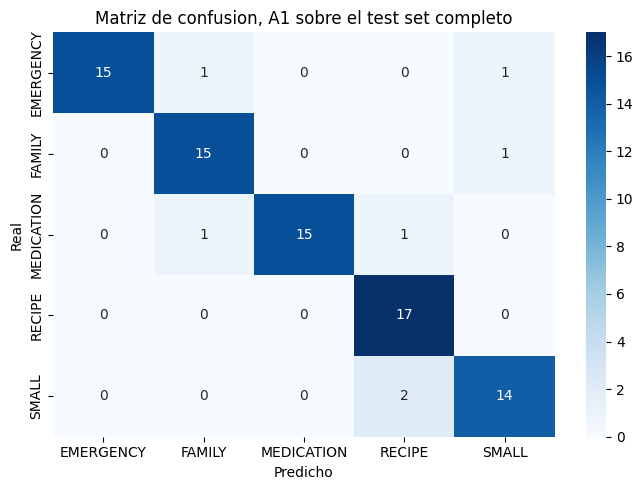

In [78]:
cm = confusion_matrix(df_a1['intencion_real'], df_a1['intencion_predicha'], labels=INTENCIONES)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ETIQUETAS_CORTAS, yticklabels=ETIQUETAS_CORTAS)
plt.title('Matriz de confusion, A1 sobre el test set completo')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

C:\Users\Manuel Pillapa\AppData\Local\Temp\ipykernel_27624\631303008.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(datos_latencia, labels=versiones, patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))


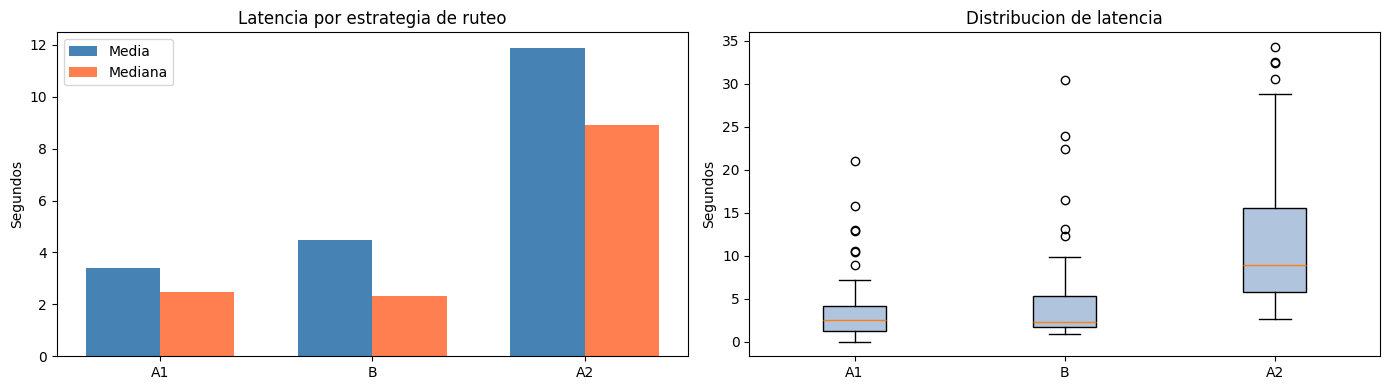

In [79]:
versiones = ['A1', 'B', 'A2']
medias   = [df_resumen.loc[v, 'latencia_media']   for v in versiones]
medianas = [df_resumen.loc[v, 'latencia_mediana'] for v in versiones]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(versiones))
ancho = 0.35
axes[0].bar(x - ancho/2, medias, ancho, label='Media', color='steelblue')
axes[0].bar(x + ancho/2, medianas, ancho, label='Mediana', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(versiones)
axes[0].set_ylabel('Segundos')
axes[0].set_title('Latencia por estrategia de ruteo')
axes[0].legend()

datos_latencia = [df_ok[df_ok['version'] == v]['latencia_segundos'].values for v in versiones]
axes[1].boxplot(datos_latencia, labels=versiones, patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))
axes[1].set_ylabel('Segundos')
axes[1].set_title('Distribucion de latencia')

plt.tight_layout()
plt.show()

### Conclusiones de la comparativa

Latencia. A1 responde en 3.39 segundos de media. B en 4.48 y A2 en 11.89. A1 es 1.3 veces mas rapida que B y 3.5 veces mas rapida que A2. La ventaja crece en small talk, donde A1 responde casi al instante porque no llama al modelo de lenguaje.

Accuracy de ruteo. Solo A1 expone la intencion de forma estructurada, asi que solo en A1 se puede medir el acierto de forma exacta: 91.6 por ciento, 76 de 83. B y A2 se evaluan de forma cualitativa sobre una muestra. B acierta alrededor del 72 por ciento en el conjunto completo, con la mayoria de fallos en small talk mal enviado al puente familiar. A2 mejora a B porque el clasificador guia la decision, pero usa la herramienta de forma inconsistente y a veces ignora su salida.

Robustez. A1 es determinista. Ante el mismo texto produce siempre el mismo ruteo, lo que permite auditar y monitorear. B y A2 varian entre ejecuciones y a veces inventan nombres de agentes o devuelven respuestas meta descriptivas poco utiles para el usuario.

Recomendacion. A1 para produccion. Tiene accuracy medible, es determinista, no gasta tokens en el ruteo y sus fallos son conocidos y mejorables agregando datos al dataset. Su limite son las frases ambiguas, que se mitigan con un umbral de confianza: si la confianza es menor a 0.5, el sistema pide al usuario que reformule.

## 13. Conclusiones generales

1. La representacion importa mas que la cabeza. Con el mismo Logistic Regression, pasar de TF-IDF a embeddings MiniLM subio el F1 macro de 0.86 a 0.92 y el accuracy de 85.5 a 91.6 por ciento. La ganancia se concentra en emergencia y medicacion, las clases de mayor consecuencia.

2. Los embeddings capturan semantica que TF-IDF no ve. Frases de urgencia sin palabras clave explicitas, como pedir que venga alguien ya, se clasifican mejor porque el modelo entiende el significado y no solo la coincidencia de palabras.

3. El costo de los embeddings es despreciable en este uso. La clasificacion tarda menos de medio segundo en CPU, frente a los varios segundos que tarda el modelo de lenguaje del agente. Para un router, los embeddings son la eleccion correcta.

4. Un clasificador dedicado supera al ruteo por razonamiento del modelo de lenguaje. La estrategia A1 es mas rapida, medible y determinista que dejar que el modelo de lenguaje decida. Es la recomendacion para un sistema en produccion.

5. Los errores restantes son ambiguedades legitimas del lenguaje. De 7 errores, 6 son frases que una persona tambien dudaria como clasificar. El unico fallo de seguridad, una taquicardia enviada a comunicacion familiar, indica la siguiente mejora del dataset.

## 14. Referencias

- Reimers, N. y Gurevych, I. Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks. EMNLP 2019.
- Modelo de embeddings paraphrase-multilingual-MiniLM-L12-v2. Sentence-Transformers, Hugging Face.
- Pedregosa et al. Scikit-learn: Machine Learning in Python. JMLR 2011.
- CrewAI, framework para sistemas multiagente. https://docs.crewai.com
- Ollama, ejecucion local de modelos de lenguaje. https://ollama.com
- Modelo de lenguaje local qwen2.5:7b.
- Dataset propio de 415 frases en espanol ecuatoriano coloquial, 83 por intencion. Ver data/intents/intents_schema.md en el repositorio.